# Week 05: Embeddings
---


## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

Objectives:

1) Deep learning embeddings
2) Usage: similarity, clustering
3) GloVe: usage and finetuning


In [2]:
# set random seed
!pip install torch --upgrade
!pip install gensim
import collections
from collections import Counter

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.optim as optim
from tqdm.notebook import tqdm
import re
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from string import punctuation
nltk.download('stopwords')
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving sc_cases_cleaned.pkl to sc_cases_cleaned.pkl


In [5]:
# If you want to use gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [6]:
df = pd.read_pickle('sc_cases_cleaned.pkl',
                    compression = 'gzip')

df = df.reset_index(drop = True)
df = df.assign(authorship_id=(df['authorship']).astype('category').cat.codes) # Authorship as categorical
df['index'] = df['authorship'] + df['date_standard'].astype(str)
df.rename(columns = {'x_republican':'republican'}, inplace = True)

# Basic preprocessing for the dataset
translator = str.maketrans(' ', ' ', punctuation)
from nltk.tokenize import word_tokenize

def preprocess(doc):
  doc = doc.replace('\r', ' ').replace('\n', ' ')
  doc = re.sub(r"(\d)([A-Za-z])", r"\1 \2", doc) # separate numbers from strings
  doc = re.sub(r"([A-Za-z])(\d)", r"\1 \2", doc) # separate strings from numbers
  d = doc.translate(translator).lower() # remove punctuation
  words = word_tokenize(d)
  words = [w for w in words if w not in stoplist] # remove stopwords
  words = [w if not w.isdigit() else '#' for w in words] # normalize numbers
  output = ' '.join(words) # Let's not tokenize now
  return output

df['opinion_text_clean'] = df['opinion_text'].apply(preprocess)

In [7]:
df.head()

,case_name,opinion_type,date_standard,authorship,republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,year,log_cite_count,authorship_id,index,opinion_text_clean
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,2003,7.981392,2,GINSBURG2003-03-04,justice ginsburg delivered opinion court motio...
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,2003,4.762174,9,STEVENS2003-06-09,justice stevens delivered opinion court united...
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,2005,10.058952,4,O'CONNOR2005-03-30,justice oconnor delivered opinion court confro...
3,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,2005,4.430817,3,KENNEDY2005-06-06,justice kennedy delivered opinion court state ...
4,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,2005,8.349957,3,KENNEDY2005-06-13,justice kennedy delivered opinion court case i...


Let's try to replicate last class prediction problem (Republican or Democrat) but now using the tokenized words as inputs and with a trainable embedding layer.

### NBoW: Neural Bag of Words

The NBoW model are a strong, commonly used, baseline model for NLP tasks. They should be one of the first models you implement when performing sentiment analysis/text classification.

In [8]:
# Split the data into train and test sets (80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2,
                                     random_state=42, shuffle = True)

# Separate features (X) and labels? (y)
X_train, y_train = train_df['opinion_text_clean'], train_df['republican']
X_test, y_test = test_df['opinion_text_clean'], test_df['republican']

In [9]:
# Step 1: Tokenize Data
train_tokens = [word_tokenize(sample.lower()) for sample in X_train]
test_tokens  = [word_tokenize(sample.lower()) for sample in X_test]

# Step 2: Create Vocabulary
min_freq = 5

counter = Counter(token for sample in train_tokens for token in sample)

# <unk> = 0, <pad> = 1, then all words with frequency >= min_freq
word2idx = {"<unk>": 0, "<pad>": 1}
for word, count in counter.most_common():
    if count >= min_freq:
        word2idx[word] = len(word2idx)

unk_index = torch.tensor(0)
pad_index = torch.tensor(1)

def lookup(token):
    return word2idx.get(token, 0)  # returns <unk> index if not found

# Step 3: Numericalize Data
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test  = label_encoder.transform(y_test)

In [10]:
# Step 4: Create Data Loaders
from torch.utils.data import DataLoader

# Converts a batch of (ids, label) pairs into padded tensors
def collate_fn(batch):
    # Separate sequences and labels
    sequences = [item[0] for item in batch]
    labels    = [item[1] for item in batch]

    # Pad all sequences to the same length using <pad> index
    sequences_padded = torch.nn.utils.rnn.pad_sequence(sequences,
                                                       padding_value=pad_index,
                                                       batch_first=True)
    labels = torch.stack(labels)

    return sequences_padded, labels

# Convert tokens to index sequences
train_dataset = [(torch.tensor([lookup(t) for t in tokens]), torch.tensor(label))
                 for tokens, label in zip(train_tokens, y_train)]

test_dataset  = [(torch.tensor([lookup(t) for t in tokens]), torch.tensor(label))
                 for tokens, label in zip(test_tokens, y_test)]

# Create loaders that serve shuffled mini-batches
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                          shuffle=False, collate_fn=collate_fn)

In [11]:
class NBoW(nn.Module):
    """
    Neural Bag of Words model.
    The idea is simple:
      1. Map each word index to a dense vector (embedding)
      2. Average all word vectors in the sentence (mean pooling)
      3. Pass the result to a linear layer for classification

    This ignores word order entirely — it's just a "bag" of word vectors.
    """
    def __init__(self, vocab_size, embedding_dim, output_dim, pad_index):
        super().__init__()

        # Embedding table: one vector per word in the vocabulary
        # padding_idx means the <pad> token always gets a zero vector (ignored in mean)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)

        # Final linear layer: maps the averaged embedding to class scores
        self.fc = nn.Linear(embedding_dim, output_dim)

    def forward(self, ids):
        # ids: (batch_size, seq_len) — each value is a word index

        embedded = self.embedding(ids)
        # embedded: (batch_size, seq_len, embedding_dim) — one vector per word

        pooled = embedded.mean(dim=1)
        # pooled: (batch_size, embedding_dim) — one vector per sentence (averaged over words)

        prediction = self.fc(pooled)
        # prediction: (batch_size, output_dim) — one score per class

        return prediction

In [12]:
# Define model parameters
vocab_size = len(word2idx)
embedding_dim = 100
output_dim = 2  # Assuming binary classification (positive/negative sentiment)

# Initialize model and optimizer
model = NBoW(vocab_size, embedding_dim, output_dim, pad_index = pad_index)
optimizer = optim.Adam(model.parameters())

model = model.to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")
# Define loss function
criterion = nn.CrossEntropyLoss()

# Training loop
def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    model.train()

    for inputs, labels in iterator:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        predictions = model(inputs)
        loss = criterion(predictions, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Evaluation function
def evaluate(model, iterator, criterion):
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0

    model.eval()

    with torch.no_grad():
        for inputs, labels in iterator:
            inputs = inputs.to(device)
            labels = labels.to(device)
            predictions = model(inputs)
            loss = criterion(predictions, labels)

            epoch_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(predictions, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_predictions += labels.size(0)

    accuracy = correct_predictions / total_predictions
    return epoch_loss / len(iterator), accuracy

The model has 1,712,502 trainable parameters


In [13]:
# Training loop with evaluation

num_epochs = 10
train_losses = []
test_losses = []
test_accuracies = []

for epoch in tqdm(range(num_epochs)):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    print(f'Epoch: {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1, Train Loss: 0.7025, Test Loss: 0.6705, Test Accuracy: 0.7468
Epoch: 2, Train Loss: 0.6332, Test Loss: 0.6181, Test Accuracy: 0.7792
Epoch: 3, Train Loss: 0.5954, Test Loss: 0.5821, Test Accuracy: 0.7792
Epoch: 4, Train Loss: 0.5931, Test Loss: 0.5606, Test Accuracy: 0.7792
Epoch: 5, Train Loss: 0.5635, Test Loss: 0.5513, Test Accuracy: 0.7792
Epoch: 6, Train Loss: 0.5852, Test Loss: 0.5454, Test Accuracy: 0.7792
Epoch: 7, Train Loss: 0.5596, Test Loss: 0.5433, Test Accuracy: 0.7792
Epoch: 8, Train Loss: 0.5672, Test Loss: 0.5392, Test Accuracy: 0.7792
Epoch: 9, Train Loss: 0.5443, Test Loss: 0.5374, Test Accuracy: 0.7792
Epoch: 10, Train Loss: 0.5351, Test Loss: 0.5349, Test Accuracy: 0.7792


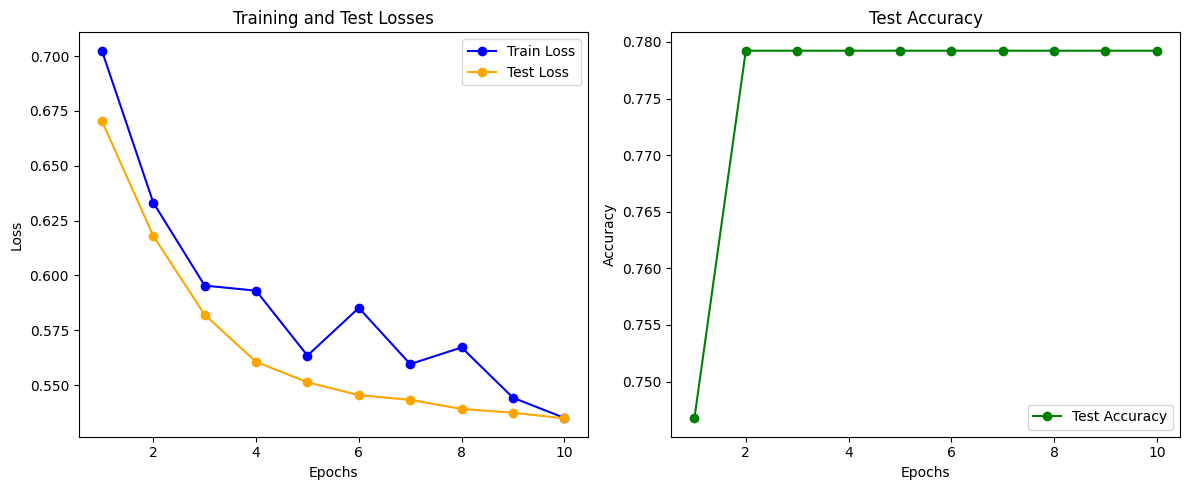

In [14]:
# Define number of epochs
epochs = range(1, num_epochs+1)

# Plotting
plt.figure(figsize=(12, 5))

# Plotting train and test losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', color='orange', marker='o')
plt.title('Training and Test Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting test accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, test_accuracies, label='Test Accuracy', color='green', marker='o')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

The embeddings have functionalities as themselves, we can extract them:

In [15]:
# Build a reverse mapping: index -> word
idx2word = {idx: word for word, idx in word2idx.items()}

# Obtain all word embeddings
model.eval()
embedding_layer = model.embedding
word_embeddings = {}

for index in range(len(word2idx)):
    word = idx2word[index]
    embedding = embedding_layer(torch.tensor([index]).long().to(device)).detach()
    word_embeddings[word] = embedding

In [16]:
from torch.nn.functional import cosine_similarity

def find_nearest_neighbors(word_embeddings, target_word, top_n=5):
    """
    Find the nearest neighbors of a target word using Cosine Similarity.
    Cosine similarity measures the angle between two vectors (ignores magnitude).
    A score of 1 means identical direction, 0 means unrelated, -1 means opposite.

    Args:
    - word_embeddings (dict): word -> embedding
    - target_word (str): the word to search neighbors for
    - top_n (int): how many neighbors to return

    Returns:
    - list of (word, similarity_score) sorted by most similar first
    """
    target_embedding = word_embeddings[target_word]

    similarities = {}
    for word, embedding in word_embeddings.items():
        if word != target_word:
            # cosine_similarity expects 2D tensors, hence the unsqueeze
            score = cosine_similarity(target_embedding, embedding, dim=1)
            similarities[word] = score.item()

    # Sort by highest similarity (most similar first)
    nearest_neighbors = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return nearest_neighbors

find_nearest_neighbors(word_embeddings, 'guilty')

[('opposed', 0.34650710225105286),
 ('undercut', 0.344642698764801),
 ('rateofreturn', 0.34326574206352234),
 ('eeoa', 0.33788877725601196),
 ('wherever', 0.33614492416381836)]

Word2Vec in gensim

In [17]:
# word2vec requires sentences as input
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk import sent_tokenize
from string import punctuation
translator = str.maketrans('','',punctuation)
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

def get_sentences(doc):
    sent=[]
    for raw in sent_tokenize(doc):
        raw2 = normalize_text(raw)
        sent.append(raw2)
    return sent

sentences = []
for doc in df['opinion_text']:
    sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

# train the model
from gensim.models import Word2Vec
w2v = Word2Vec(sentences,  # list of tokenized sentences
               workers = 8, # Number of threads to run in parallel
               vector_size=300,  # Word vector dimensionality
               min_count =  25, # Minimum word count
               window = 5, # Context window size
               sample = 1e-3, # Downsample setting for frequent words
               )

# done training, so delete context vectors
w2v.init_sims(replace=True)

w2v.save('w2v-vectors.pkl')

w2v.wv['judg'] # vector for "judge"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.4 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/tmp/ipython-input-2146950650.py:50: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v.init_sims(replace=True)


array([-0.01292587,  0.11427729,  0.05548802, -0.02343508,  0.03204123,
       -0.05378942, -0.04150117, -0.13319519, -0.0027484 , -0.04772666,
        0.06836271, -0.01999726,  0.05714097, -0.1183385 ,  0.0090057 ,
       -0.02603864,  0.04114524,  0.02980449, -0.0905219 ,  0.09728273,
        0.07948233, -0.04633094,  0.00792286, -0.04092329, -0.06733917,
        0.02830398, -0.01011727, -0.00806877,  0.05910237,  0.08107671,
        0.0106614 ,  0.01865532, -0.06567856,  0.00338841,  0.00560758,
       -0.01443242,  0.02094535, -0.05824329,  0.00607661,  0.01417424,
        0.11103984,  0.02743449,  0.04946723, -0.06756911, -0.01229023,
       -0.02854132,  0.00802657, -0.01202103, -0.14193766, -0.01339479,
        0.01199117, -0.08224294, -0.05184913, -0.07485697, -0.05558364,
       -0.05371369,  0.07419518,  0.08267356,  0.0026269 ,  0.03653671,
       -0.03557096,  0.0292427 ,  0.08022468, -0.06767832,  0.07187996,
       -0.03035865,  0.0192443 , -0.01938   ,  0.01900981, -0.12

In [18]:
w2v.wv.similarity('judg','juri') # similarity

np.float32(0.5374804)

In [19]:
w2v.wv.most_similar('judg') # most similar words

[('bench', 0.6121833920478821),
 ('court', 0.5441443920135498),
 ('juri', 0.537480354309082),
 ('unanim', 0.5274754762649536),
 ('panel', 0.5176411271095276),
 ('magistr', 0.5150997042655945),
 ('imparti', 0.5093593001365662),
 ('factfind', 0.49348294734954834),
 ('speedi', 0.49175408482551575),
 ('mistrial', 0.4758850038051605)]

In [20]:
# analogies: judge is to man as __ is to woman
w2v.wv.most_similar(positive=['judg','man'],
                 negative=['woman'])

[('bench', 0.576799213886261),
 ('magistr', 0.5369584560394287),
 ('unanim', 0.5243895053863525),
 ('panel', 0.5003776550292969),
 ('sit', 0.4710722267627716),
 ('juri', 0.4683836102485657),
 ('prosecutor', 0.4576330780982971),
 ('court', 0.45235368609428406),
 ('mistrial', 0.4394316077232361),
 ('ought', 0.4368254542350769)]

In [21]:
# Word2Vec: K-Means Clusters
from sklearn.cluster import KMeans
kmw = KMeans(n_clusters=50)
kmw.fit(w2v.wv.vectors)
judge_clust = kmw.labels_[w2v.wv.key_to_index['judg']]
for i, cluster in enumerate(kmw.labels_):
    if cluster == judge_clust and i<=100:
        print(w2v.wv.index_to_key[i])

state
case
feder
rule
whether
reason
govern
also
constitut
question
issu
must
decis
determin
general
fact
even
applic
new
howev
judg


GloVe

GloVe embeddings as NN inputs

In [23]:
!gdown 1avykMlpaYg_x6tzwF4hHoOkRxNGLkDrL
# https://drive.google.com/file/d/1avykMlpaYg_x6tzwF4hHoOkRxNGLkDrL/view?usp=share_link

Downloading...
From (original): https://drive.google.com/uc?id=1avykMlpaYg_x6tzwF4hHoOkRxNGLkDrL
From (redirected): https://drive.google.com/uc?id=1avykMlpaYg_x6tzwF4hHoOkRxNGLkDrL&confirm=t&uuid=dae0a694-1d4f-45bc-9037-f49777b874de
To: /content/glove.6B.50d.txt
100% 171M/171M [00:06<00:00, 28.0MB/s]


In [24]:
glove = {}
with open (r'glove.6B.50d.txt', 'rb') as f:
  for line in f:
    parts = line.split()
    word = parts[0].decode('utf-8')
    vector = np.array(parts[1:], dtype=np.float32)
    glove[word] = vector

In [25]:
# Split the data into train and test sets (80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2,
                                     random_state=42, shuffle = True)

# Separate features (X) and labels? (y)
X_train, y_train = train_df['opinion_text_clean'], train_df['republican']
X_test, y_test = test_df['opinion_text_clean'], test_df['republican']

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [26]:
def sentence_to_tensor(sentence, embedding_dict):
    # Split the sentence into words
    words = sentence.split()
    # Initialize an empty list to store vectors
    vectors = []
    for word in words:
        # Retrieve the vector for each word from the GloVe dictionary
        vector = embedding_dict.get(word.lower())
        if vector is not None:
            # Convert the vector to a PyTorch tensor
            tensor = torch.tensor(vector, dtype=torch.float)
            # Append the tensor to the list
            vectors.append(tensor)
    # Stack the list of tensors along a new dimension to form a 3D tensor
    tensor = torch.stack(vectors, dim=0)
    # Calculate the mean along the first dimension to get a single vector
    tensor_mean = torch.mean(tensor, dim=0)
    return tensor_mean

# Apply the function to each review in the DataFrame
train_df['opinion_tensors'] = train_df['opinion_text_clean'].apply(lambda x: sentence_to_tensor(x, glove))

In [27]:
# Apply the function to each review in the DataFrame
train_df['opinion_tensors'] = train_df['opinion_text_clean'].apply(lambda x: sentence_to_tensor(x, glove))
test_df['opinion_tensors'] = test_df['opinion_text_clean'].apply(lambda x: sentence_to_tensor(x, glove))

In [28]:
batch_size = 32
# Create DataLoader instances for train and test data
train_dataset = [(torch.tensor(ids), torch.tensor(label)) for ids, label in zip(train_df['opinion_tensors'], y_train)]
test_dataset = [(torch.tensor(ids), torch.tensor(label)) for ids, label in zip(test_df['opinion_tensors'], y_test)]

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

/tmp/ipython-input-1233009446.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_dataset = [(torch.tensor(ids), torch.tensor(label)) for ids, label in zip(train_df['opinion_tensors'], y_train)]
/tmp/ipython-input-1233009446.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset = [(torch.tensor(ids), torch.tensor(label)) for ids, label in zip(test_df['opinion_tensors'], y_test)]


In [29]:
class SimpleNN(nn.Module):
    def __init__(self, embedding_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(embedding_dim, output_dim)

    def forward(self, pooled):
        # pooled = [batch size, embedding dim]
        prediction = self.fc(pooled)
        # prediction = [batch size, output dim]
        return prediction

In [30]:
# Define model parameters
embedding_dim = 50
output_dim = 2  # Assuming binary classification (positive/negative sentiment)

# Initialize model and optimizer
model = SimpleNN(embedding_dim, output_dim)
optimizer = optim.Adam(model.parameters())


model = model.to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")
# Define loss function
criterion = nn.CrossEntropyLoss()

# Training loop
def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    model.train()

    for inputs, labels in iterator:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        predictions = model(inputs)
        loss = criterion(predictions, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# Evaluation function
def evaluate(model, iterator, criterion):
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0

    model.eval()

    with torch.no_grad():
        for inputs, labels in iterator:
            inputs = inputs.to(device)
            labels = labels.to(device)
            predictions = model(inputs)
            loss = criterion(predictions, labels)

            epoch_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(predictions, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_predictions += labels.size(0)

    accuracy = correct_predictions / total_predictions
    return epoch_loss / len(iterator), accuracy


The model has 102 trainable parameters


In [31]:
# Training loop with evaluation
num_epochs = 10
train_losses = []
test_losses = []
test_accuracies = []
for epoch in tqdm(range(num_epochs)):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    print(f'Epoch: {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1, Train Loss: 0.5467, Test Loss: 0.5296, Test Accuracy: 0.7792
Epoch: 2, Train Loss: 0.5454, Test Loss: 0.5257, Test Accuracy: 0.7792
Epoch: 3, Train Loss: 0.5272, Test Loss: 0.5248, Test Accuracy: 0.7792
Epoch: 4, Train Loss: 0.5349, Test Loss: 0.5236, Test Accuracy: 0.7792
Epoch: 5, Train Loss: 0.5346, Test Loss: 0.5230, Test Accuracy: 0.7792
Epoch: 6, Train Loss: 0.5338, Test Loss: 0.5220, Test Accuracy: 0.7792
Epoch: 7, Train Loss: 0.5418, Test Loss: 0.5211, Test Accuracy: 0.7792
Epoch: 8, Train Loss: 0.5324, Test Loss: 0.5209, Test Accuracy: 0.7792
Epoch: 9, Train Loss: 0.5418, Test Loss: 0.5199, Test Accuracy: 0.7792
Epoch: 10, Train Loss: 0.5243, Test Loss: 0.5197, Test Accuracy: 0.7792


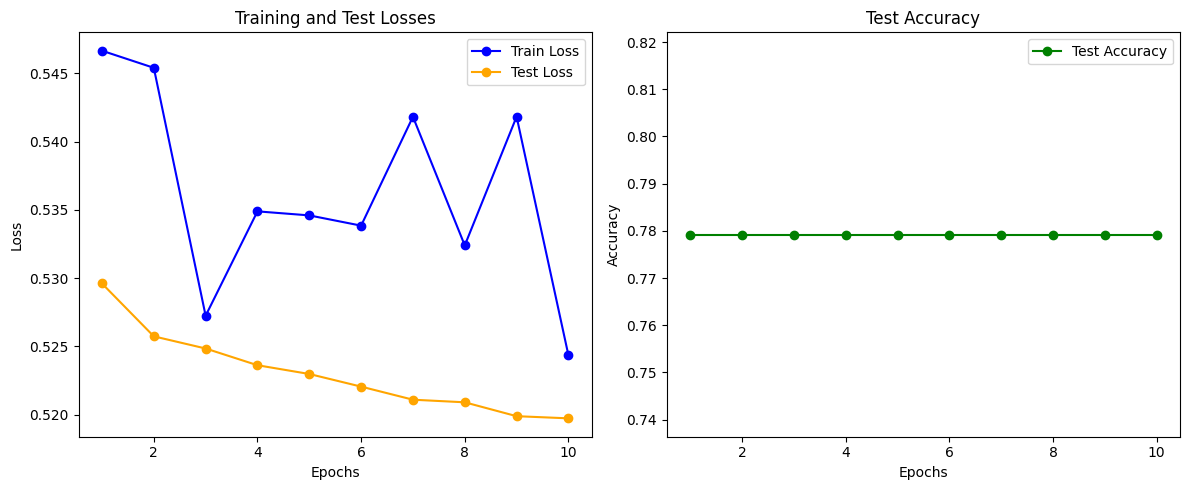

In [32]:
# Define number of epochs
epochs = range(1, num_epochs+1)

# Plotting
plt.figure(figsize=(12, 5))

# Plotting train and test losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', color='orange', marker='o')
plt.title('Training and Test Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting test accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, test_accuracies, label='Test Accuracy', color='green', marker='o')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()